In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [49]:
df = pd.read_csv("../data/master_dataset_v1.csv")
df

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,29.85,0,1,0,0,0,0,1,0
1,0,0,0,34,1,0,1,0,56.95,0,1,0,0,0,0,0,1
2,0,0,0,2,1,0,0,1,53.85,1,1,0,0,0,0,0,1
3,0,0,0,45,1,1,1,0,42.30,0,1,0,0,1,0,0,0
4,0,0,0,2,0,0,0,1,70.70,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,1,84.80,0,1,0,0,0,0,0,1
7039,0,1,1,72,0,0,1,1,103.20,0,0,1,0,0,1,0,0
7040,0,1,1,11,1,0,0,1,29.60,0,1,0,0,0,0,1,0
7041,1,1,0,4,0,0,0,1,74.40,1,0,1,0,0,0,0,1


In [50]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [51]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [53]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)


<BarContainer object of 2 artists>

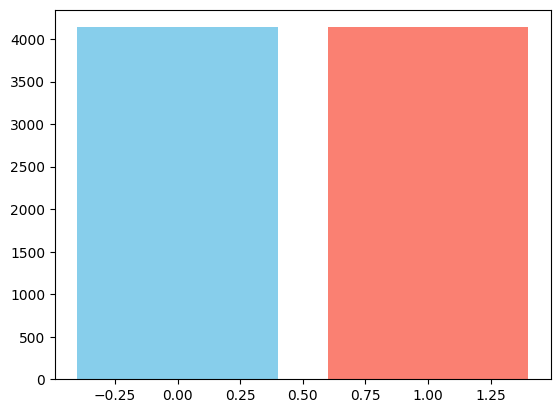

In [54]:
from imblearn.over_sampling import SMOTE

bal = SMOTE(sampling_strategy="minority", random_state=42)

X_bal_train, y_bal_train = bal.fit_resample(X_scaled_train, y_train)

plt.bar(y_bal_train.value_counts().index, y_bal_train.value_counts().values, 
        color=['skyblue','salmon'])


In [55]:
logistic_model = LogisticRegression()

logistic_model.fit(X_bal_train, y_bal_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
y_pred = logistic_model.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, y_pred)}")
print(f"roc_auc: {roc_auc_score(y_test, y_pred)}")
print(f"classification_report: {classification_report(y_test, y_pred)}")

accuracy: 0.6444286728176012
roc_auc: 0.7246725567697435
classification_report:               precision    recall  f1-score   support

           0       0.94      0.55      0.70      1035
           1       0.42      0.90      0.57       374

    accuracy                           0.64      1409
   macro avg       0.68      0.72      0.63      1409
weighted avg       0.80      0.64      0.66      1409



/Users/yashwanthkumar/Desktop/Desktop/ML project/Retention-ROI-System/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  useful for meta-estimator which can delegate input validation to


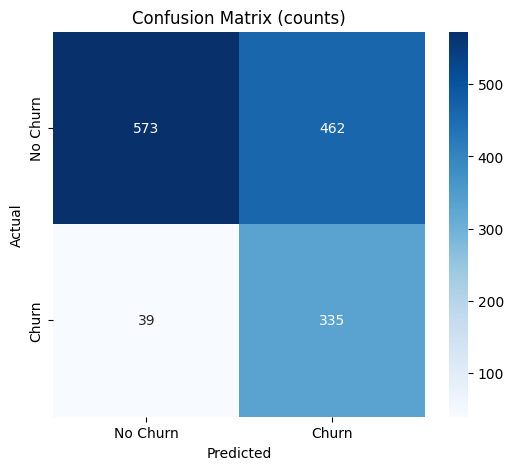

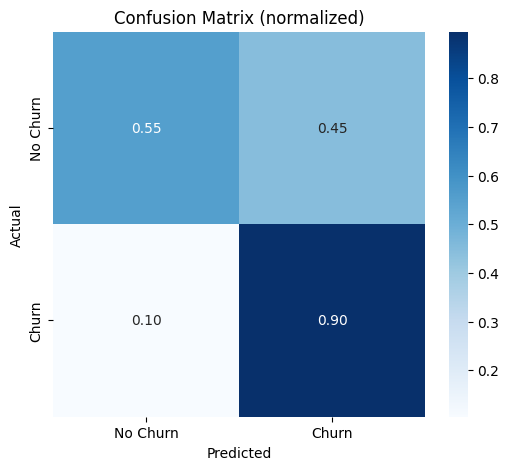

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# raw counts
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (counts)')
plt.show()

# normalized (by true labels)
cmn = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (normalized)')
plt.show()


In [58]:
y_bal_train.value_counts()

Churn
0    4139
1    4139
Name: count, dtype: int64

accuracy : 0.7679205110007097
classification report:               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.55      0.66      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

[[9.9965638e-01 3.4362008e-04]
 [5.6294024e-02 9.4370598e-01]
 [8.5634637e-01 1.4365366e-01]
 ...
 [7.1318901e-01 2.8681099e-01]
 [8.2557505e-01 1.7442493e-01]
 [9.9872208e-01 1.2779466e-03]]


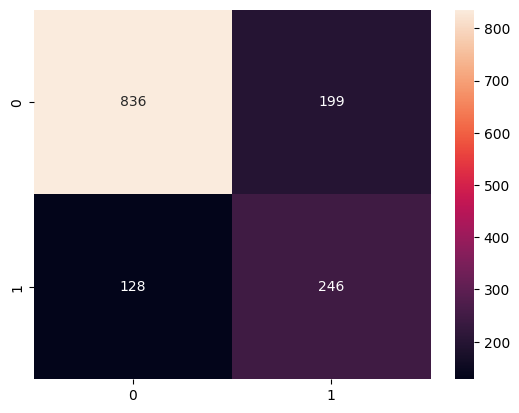

In [59]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_bal_train, y_bal_train)

y_pred = xgb.predict(X_scaled_test)
y_prob = xgb.predict_proba(X_scaled_test)

print(f'accuracy : {accuracy_score(y_test, y_pred)}')
print(f'classification report: {classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt = 'd')
print(y_prob)


[LightGBM] [Info] Number of positive: 4139, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 914
[LightGBM] [Info] Number of data points in the train set: 8278, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
accuracy : 0.7757274662881476
classification report:               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



/Users/yashwanthkumar/Desktop/Desktop/ML project/Retention-ROI-System/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  


<Axes: >

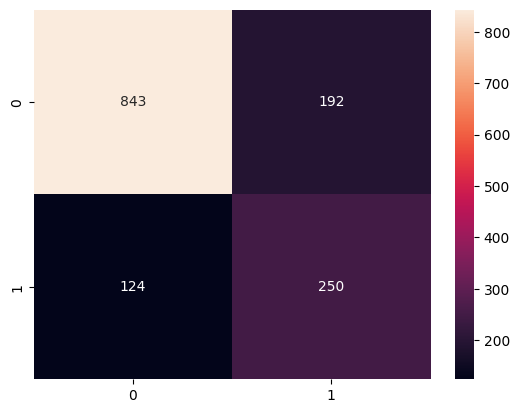

In [60]:
from imblearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

pipe = Pipeline([
    ('scaler' , StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier())
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print(f'accuracy : {accuracy_score(y_test, y_pred)}')
print(f'classification report: {classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt = 'd')

[16:50:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

/Users/yashwanthkumar/Desktop/Desktop/ML project/Retention-ROI-System/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  


Best threshold: 0.10 | Min business cost: $9,210
Best threshold: 0.10 | Min business cost: $10,690

  XGBoost
  AUC-ROC  : 0.8333
  AUC-PR   : 0.6429  ← PRIMARY METRIC
  Brier    : 0.1527  ← calibration (lower=better)
  F1 Score : 0.5591

              precision    recall  f1-score   support

        Stay       0.96      0.48      0.64      1035
       Churn       0.40      0.95      0.56       374

    accuracy                           0.60      1409
   macro avg       0.68      0.71      0.60      1409
weighted avg       0.81      0.60      0.62      1409


  LightGBM
  AUC-ROC  : 0.8312
  AUC-PR   : 0.6414  ← PRIMARY METRIC
  Brier    : 0.1502  ← calibration (lower=better)
  F1 Score : 0.5631

              precision    recall  f1-score   support

        Stay       0.95      0.51      0.66      1035
       Churn       0.40      0.93      0.56       374

    accuracy                           0.62      1409
   macro avg       0.68      0.72      0.61      1409
weighted avg       0.

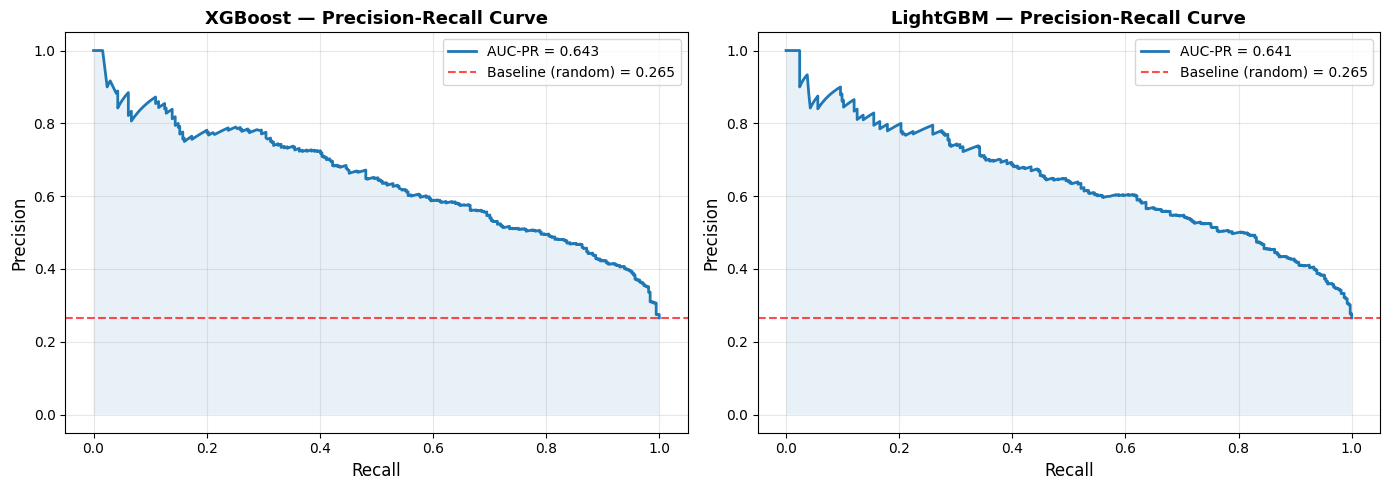

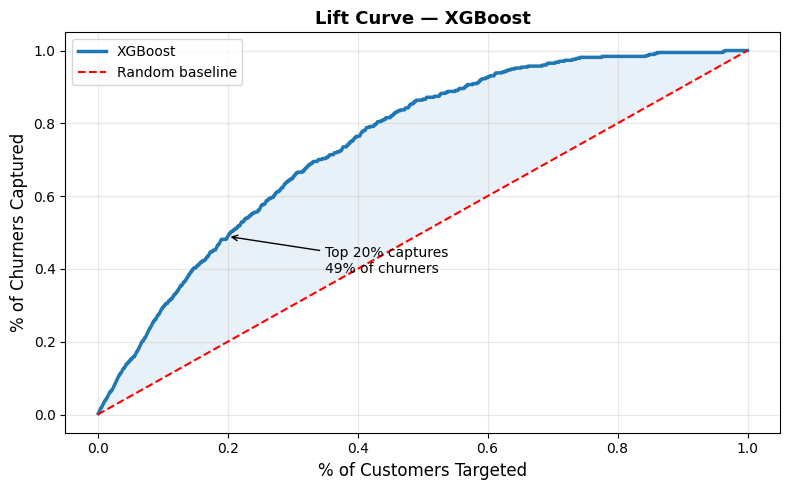

Top 20% of customers → captures 49% of all churners


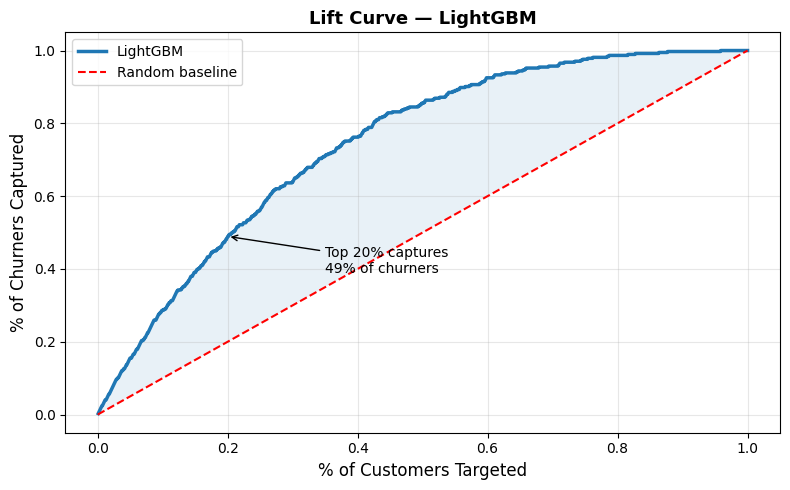

Top 20% of customers → captures 49% of all churners


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, brier_score_loss, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ─────────────────────────────────────────────
# 1. PIPELINES — clean, no leakage
# ─────────────────────────────────────────────

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=1,       # let SMOTE handle balance, not this
        use_label_encoder=False,
        eval_metric='aucpr',      # optimize for AUC-PR, not logloss
        random_state=42
    ))
])

lgbm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    ))
])

# ─────────────────────────────────────────────
# 2. FIT
# ─────────────────────────────────────────────

xgb_pipe.fit(X_train, y_train)
lgbm_pipe.fit(X_train, y_train)

# ─────────────────────────────────────────────
# 3. PROBABILITIES — always use predict_proba
# ─────────────────────────────────────────────

xgb_probs  = xgb_pipe.predict_proba(X_test)[:, 1]
lgbm_probs = lgbm_pipe.predict_proba(X_test)[:, 1]

# ─────────────────────────────────────────────
# 4. THRESHOLD TUNING — not default 0.5
# Business logic: false negative (missing a churner) costs ~$200
# False positive (wasted discount) costs ~$10
# So we want high recall. Tune threshold accordingly.
# ─────────────────────────────────────────────

def find_best_threshold(probs, y_true, cost_fn=200, cost_fp=10):
    """Find threshold that minimizes total business cost."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    costs = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        tn, fp, fn, tp = cm.ravel()
        total_cost = (fn * cost_fn) + (fp * cost_fp)
        costs.append(total_cost)
    best_threshold = thresholds[np.argmin(costs)]
    print(f"Best threshold: {best_threshold:.2f} | Min business cost: ${min(costs):,}")
    return best_threshold

xgb_threshold  = find_best_threshold(xgb_probs, y_test)
lgbm_threshold = find_best_threshold(lgbm_probs, y_test)

xgb_preds  = (xgb_probs  >= xgb_threshold).astype(int)
lgbm_preds = (lgbm_probs >= lgbm_threshold).astype(int)

# ─────────────────────────────────────────────
# 5. METRICS THAT ACTUALLY MATTER
# ─────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  AUC-PR   : {average_precision_score(y_true, y_prob):.4f}  ← PRIMARY METRIC")
    print(f"  Brier    : {brier_score_loss(y_true, y_prob):.4f}  ← calibration (lower=better)")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Stay', 'Churn'])}")

evaluate_model("XGBoost",  y_test, xgb_preds,  xgb_probs)
evaluate_model("LightGBM", y_test, lgbm_preds, lgbm_probs)

# ─────────────────────────────────────────────
# 6. PRECISION-RECALL CURVE — not ROC curve
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, probs) in zip(axes, [("XGBoost", xgb_probs), ("LightGBM", lgbm_probs)]):
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)
    baseline = y_test.mean()  # random classifier baseline

    ax.plot(recall, precision, linewidth=2, label=f'AUC-PR = {auc_pr:.3f}')
    ax.axhline(y=baseline, color='red', linestyle='--', alpha=0.7,
               label=f'Baseline (random) = {baseline:.3f}')
    ax.fill_between(recall, precision, alpha=0.1)
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'{name} — Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 7. BUSINESS LIFT CURVE — what recruiters care about
# ─────────────────────────────────────────────

def plot_lift_curve(y_true, y_prob, model_name):
    """
    Shows: if you target the top X% of customers by churn probability,
    what % of actual churners do you capture?
    """
    df = pd.DataFrame({'prob': y_prob, 'actual': y_true})
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)
    
    # Cumulative % of population targeted vs. % of churners captured
    df['cum_churners'] = df['actual'].cumsum()
    df['pct_population'] = (df.index + 1) / len(df)
    df['pct_churners_captured'] = df['cum_churners'] / df['actual'].sum()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df['pct_population'], df['pct_churners_captured'],
            linewidth=2.5, label=f'{model_name}')
    ax.plot([0, 1], [0, 1], 'r--', label='Random baseline')
    ax.fill_between(df['pct_population'],
                    df['pct_churners_captured'],
                    df['pct_population'], alpha=0.1)
    
    # Mark the 20% targeting point — key business insight
    idx_20 = int(0.20 * len(df))
    captured_20 = df['pct_churners_captured'].iloc[idx_20]
    ax.annotate(f'Top 20% captures\n{captured_20:.0%} of churners',
                xy=(0.20, captured_20),
                xytext=(0.35, captured_20 - 0.1),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10)
    
    ax.set_xlabel('% of Customers Targeted', fontsize=12)
    ax.set_ylabel('% of Churners Captured', fontsize=12)
    ax.set_title(f'Lift Curve — {model_name}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'lift_curve_{model_name.lower()}.png', dpi=150)
    plt.show()
    print(f"Top 20% of customers → captures {captured_20:.0%} of all churners")

plot_lift_curve(y_test, xgb_probs,  "XGBoost")
plot_lift_curve(y_test, lgbm_probs, "LightGBM")


───────────────────────────────────────────────────────
  Threshold Strategy Comparison (min precision=50%)
───────────────────────────────────────────────────────
  Best F1      → threshold=0.49 | P=0.56 | R=0.70 | F1=0.62
  Best Recall  → threshold=0.36 | P=0.50 | R=0.79 | F1=0.61
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  Threshold Strategy Comparison (min precision=50%)
───────────────────────────────────────────────────────
  Best F1      → threshold=0.30 | P=0.50 | R=0.81 | F1=0.62
  Best Recall  → threshold=0.30 | P=0.50 | R=0.81 | F1=0.62
───────────────────────────────────────────────────────

  XGBoost (corrected threshold)
  AUC-ROC  : 0.8333
  AUC-PR   : 0.6429  ← PRIMARY METRIC
  Brier    : 0.1527  ← calibration (lower=better)
  F1 Score : 0.6183

              precision    recall  f1-score   support

        Stay       0.88      0.80      0.84      1035
       Churn       0.56      0.70      0.62    

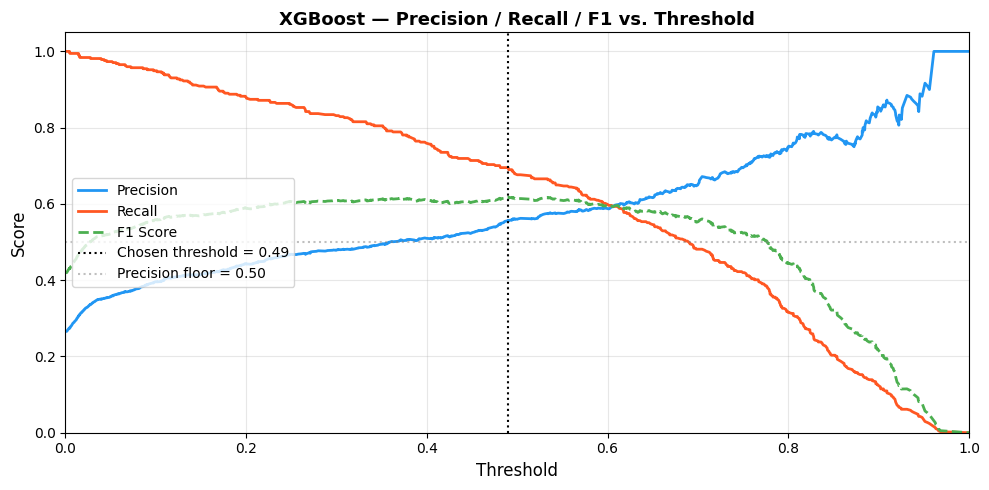

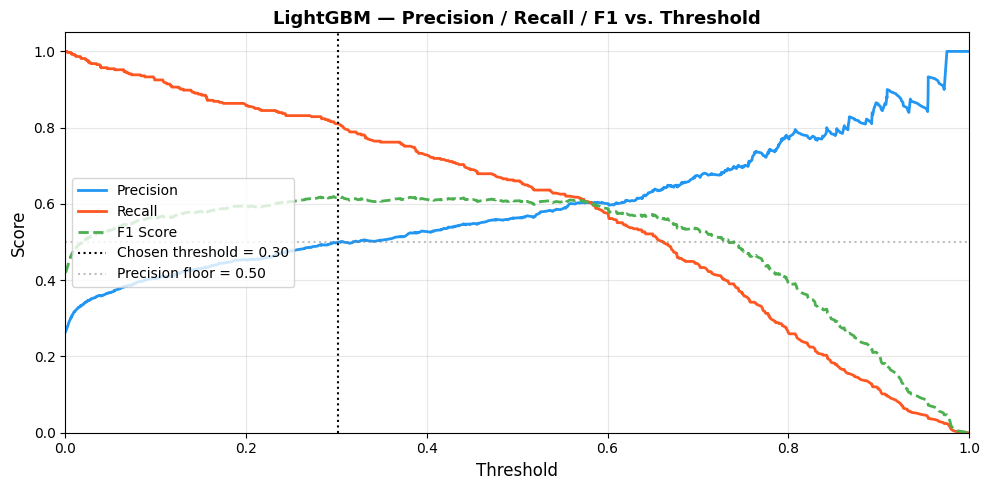

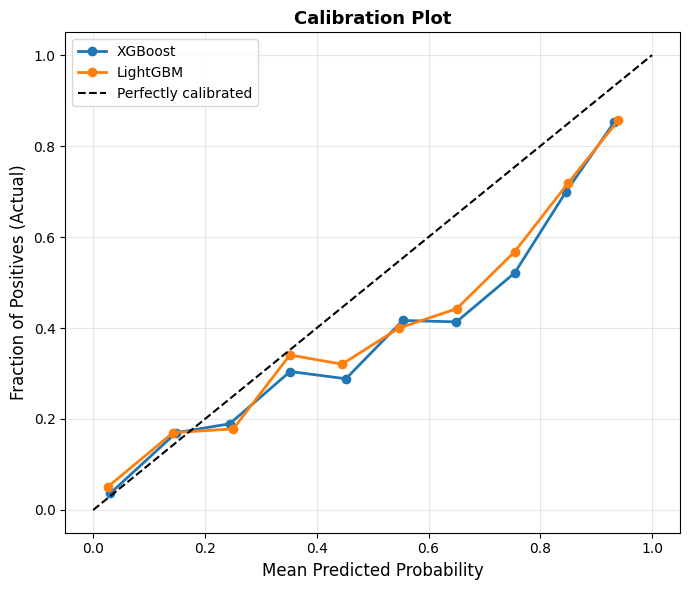

In [62]:
# ─────────────────────────────────────────────
# PROBLEM: threshold 0.10 is too aggressive
# At 0.10 → precision=0.40, recall=0.95
# You're calling 60% of your interventions wasted
#
# FIX: Either adjust cost ratio OR
# find threshold that maximizes F1 (balanced)
# OR use a precision floor constraint
# ─────────────────────────────────────────────

def find_best_threshold_v2(probs, y_true, min_precision=0.50):
    """
    Find highest recall threshold where precision >= min_precision.
    More realistic than pure cost minimization.
    This is what a real business would want:
    'Flag churners, but don't waste >50% of our retention calls'
    """
    from sklearn.metrics import precision_recall_curve, f1_score
    
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, probs)
    
    results = []
    for i, t in enumerate(thresholds):
        if precision_vals[i] >= min_precision:
            preds = (probs >= t).astype(int)
            f1 = f1_score(y_true, preds)
            results.append({
                'threshold': t,
                'precision': precision_vals[i],
                'recall': recall_vals[i],
                'f1': f1
            })
    
    results_df = pd.DataFrame(results)
    
    # Strategy 1: Maximize F1 with precision >= 0.50
    best_f1_row = results_df.loc[results_df['f1'].idxmax()]
    
    # Strategy 2: Maximize recall with precision >= 0.50  
    best_recall_row = results_df.loc[results_df['recall'].idxmax()]
    
    print(f"\n{'─'*55}")
    print(f"  Threshold Strategy Comparison (min precision=50%)")
    print(f"{'─'*55}")
    print(f"  Best F1      → threshold={best_f1_row['threshold']:.2f} | "
          f"P={best_f1_row['precision']:.2f} | R={best_f1_row['recall']:.2f} | F1={best_f1_row['f1']:.2f}")
    print(f"  Best Recall  → threshold={best_recall_row['threshold']:.2f} | "
          f"P={best_recall_row['precision']:.2f} | R={best_recall_row['recall']:.2f} | F1={best_recall_row['f1']:.2f}")
    print(f"{'─'*55}")
    
    return best_f1_row['threshold'], best_recall_row['threshold'], results_df


# Run it for both models
xgb_t_f1, xgb_t_recall, xgb_thresh_df = find_best_threshold_v2(xgb_probs, y_test, min_precision=0.50)
lgbm_t_f1, lgbm_t_recall, lgbm_thresh_df = find_best_threshold_v2(lgbm_probs, y_test, min_precision=0.50)

# Use the F1-maximizing threshold
xgb_preds_final  = (xgb_probs  >= xgb_t_f1).astype(int)
lgbm_preds_final = (lgbm_probs >= lgbm_t_f1).astype(int)

# Re-evaluate with corrected thresholds
evaluate_model("XGBoost (corrected threshold)",  y_test, xgb_preds_final,  xgb_probs)
evaluate_model("LightGBM (corrected threshold)", y_test, lgbm_preds_final, lgbm_probs)


# ─────────────────────────────────────────────
# PRECISION-RECALL TRADEOFF PLOT
# Shows recruiter you understand the business tradeoff
# ─────────────────────────────────────────────

def plot_threshold_tradeoff(probs, y_true, chosen_threshold, model_name):
    from sklearn.metrics import precision_recall_curve
    
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, probs)
    thresholds = np.append(thresholds, 1.0)

    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(thresholds, precision_vals, label='Precision', color='#2196F3', linewidth=2)
    ax.plot(thresholds, recall_vals,    label='Recall',    color='#FF5722', linewidth=2)
    
    # F1 at each threshold
    f1_vals = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
    ax.plot(thresholds, f1_vals, label='F1 Score', color='#4CAF50', linewidth=2, linestyle='--')
    
    # Mark chosen threshold
    ax.axvline(x=chosen_threshold, color='black', linestyle=':', linewidth=1.5,
               label=f'Chosen threshold = {chosen_threshold:.2f}')
    ax.axhline(y=0.50, color='gray', linestyle=':', alpha=0.5, label='Precision floor = 0.50')
    
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{model_name} — Precision / Recall / F1 vs. Threshold', fontsize=13, fontweight='bold')
    ax.legend(loc='center left')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.savefig(f'threshold_tradeoff_{model_name.lower()}.png', dpi=150)
    plt.show()

plot_threshold_tradeoff(xgb_probs,  y_test, xgb_t_f1,  "XGBoost")
plot_threshold_tradeoff(lgbm_probs, y_test, lgbm_t_f1, "LightGBM")


# ─────────────────────────────────────────────
# CALIBRATION PLOT — proves your probabilities are trustworthy
# Required before uplift model
# ─────────────────────────────────────────────

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for name, probs in [("XGBoost", xgb_probs), ("LightGBM", lgbm_probs)]:
    fraction_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, fraction_pos, marker='o', linewidth=2, label=name)

ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Actual)', fontsize=12)
ax.set_title('Calibration Plot', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# ALSO FIX: the feature names warning
# Your pipeline was fitted with feature names but
# you're passing numpy arrays somewhere.
# Make sure X_test is a DataFrame, not numpy array.
# ─────────────────────────────────────────────

# If X_test is numpy, convert it:
# X_test = pd.DataFrame(X_test, columns=feature_names)
# where feature_names = X_train.columns.tolist()

sklearn version: 1.9.0
Using FrozenEstimator (sklearn >= 1.6)


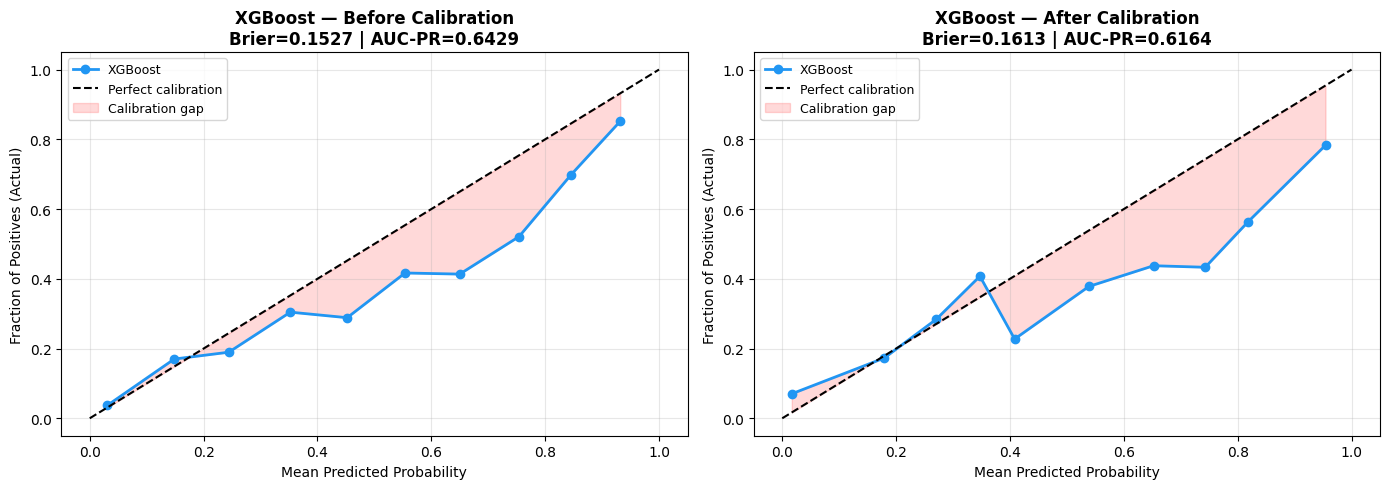


──────────────────────────────────────────────────
  Best threshold (max F1, precision≥50%)
──────────────────────────────────────────────────
  Threshold : 0.5393
  Precision : 0.5544
  Recall    : 0.6952
  F1        : 0.6168
──────────────────────────────────────────────────

  XGBoost — Calibrated Final Results
  AUC-ROC  : 0.8297
  AUC-PR   : 0.6164  ← PRIMARY METRIC
  Brier    : 0.1613  ← calibration quality
  F1 Score : 0.6168

              precision    recall  f1-score   support

        Stay       0.88      0.80      0.84      1035
       Churn       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



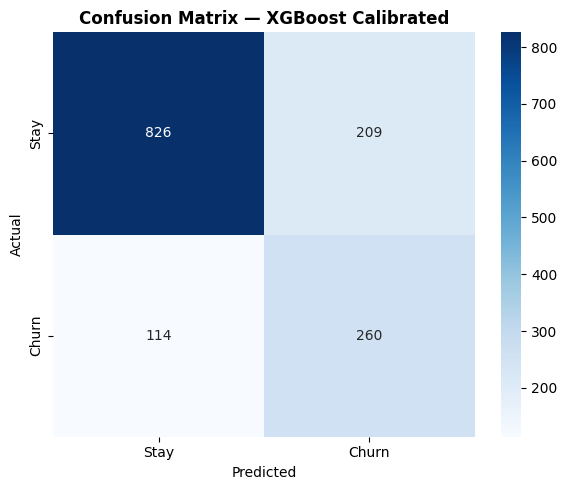

✅ Saved:
   models/xgb_base.pkl        → for SHAP
   models/xgb_calibrated.pkl  → for production scoring
   models/scaler.pkl          → for inference pipeline
  models/threshold.txt       → 0.5393
   models/test_scored.csv     → for SHAP + dashboard


In [64]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ─────────────────────────────────────────────
# STEP 1: GET TRANSFORMED DATA
# Preprocessing-only pipeline (scaler + SMOTE for train)
# ─────────────────────────────────────────────

preprocess_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42))
])
X_train_transformed, y_train_resampled = preprocess_pipe.fit_resample(X_train, y_train)

# Scaler only for test (no SMOTE on test data — ever)
scaler_only = SklearnPipeline([('scaler', StandardScaler())])
scaler_only.fit(X_train)
X_test_transformed = scaler_only.transform(X_test)

# Keep as DataFrames to avoid feature name warnings
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_test_transformed  = pd.DataFrame(X_test_transformed,  columns=X_train.columns)

# ─────────────────────────────────────────────
# STEP 2: TRAIN BASE XGBoost
# ─────────────────────────────────────────────

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='aucpr',
    random_state=42
)
xgb_base.fit(X_train_transformed, y_train_resampled)

# Raw (uncalibrated) probabilities on test
xgb_probs_raw = xgb_base.predict_proba(X_test_transformed)[:, 1]

# ─────────────────────────────────────────────
# STEP 3: CALIBRATE
# Split train data into train/calibration sets
# ─────────────────────────────────────────────

X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train_transformed, y_train_resampled,
    test_size=0.2, random_state=42, stratify=y_train_resampled
)

# Check sklearn version and pick the right approach
import sklearn
sklearn_version = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
print(f"sklearn version: {sklearn.__version__}")

if sklearn_version >= (1, 6):
    # sklearn 1.6+ — use FrozenEstimator
    from sklearn.frozen import FrozenEstimator
    print("Using FrozenEstimator (sklearn >= 1.6)")
    xgb_calibrated = CalibratedClassifierCV(
        FrozenEstimator(xgb_base),
        method='isotonic'
    )
    xgb_calibrated.fit(X_cal, y_cal)

else:
    # sklearn 1.2–1.5 — retrain with cross-val calibration
    print("Using cv=5 calibration (sklearn < 1.6)")
    xgb_calibrated = CalibratedClassifierCV(
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            eval_metric='aucpr',
            random_state=42
        ),
        method='isotonic',
        cv=5
    )
    xgb_calibrated.fit(X_train_transformed, y_train_resampled)

# Calibrated probabilities
xgb_probs_cal = xgb_calibrated.predict_proba(X_test_transformed)[:, 1]

# ─────────────────────────────────────────────
# STEP 4: BEFORE vs. AFTER CALIBRATION PLOT
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, probs) in zip(axes, [
    ("Before Calibration", xgb_probs_raw),
    ("After Calibration",  xgb_probs_cal)
]):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    brier  = brier_score_loss(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)

    ax.plot(mean_pred, frac_pos, marker='o', linewidth=2,
            color='#2196F3', label=f'XGBoost')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    alpha=0.15, color='red', label='Calibration gap')

    ax.set_title(f'XGBoost — {label}\nBrier={brier:.4f} | AUC-PR={auc_pr:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives (Actual)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# STEP 5: THRESHOLD ON CALIBRATED PROBABILITIES
# ─────────────────────────────────────────────

def find_best_threshold_v2(probs, y_true, min_precision=0.50):
    from sklearn.metrics import precision_recall_curve, f1_score

    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, probs)

    results = []
    for i, t in enumerate(thresholds):
        if precision_vals[i] >= min_precision:
            preds = (probs >= t).astype(int)
            f1 = f1_score(y_true, preds)
            results.append({
                'threshold': round(float(t), 4),
                'precision': round(float(precision_vals[i]), 4),
                'recall':    round(float(recall_vals[i]), 4),
                'f1':        round(float(f1), 4)
            })

    if not results:
        print("⚠️  No threshold achieved min_precision=0.50. Lowering to 0.40.")
        return find_best_threshold_v2(probs, y_true, min_precision=0.40)

    results_df = pd.DataFrame(results)
    best_row   = results_df.loc[results_df['f1'].idxmax()]

    print(f"\n{'─'*50}")
    print(f"  Best threshold (max F1, precision≥50%)")
    print(f"{'─'*50}")
    print(f"  Threshold : {best_row['threshold']}")
    print(f"  Precision : {best_row['precision']}")
    print(f"  Recall    : {best_row['recall']}")
    print(f"  F1        : {best_row['f1']}")
    print(f"{'─'*50}\n")

    return best_row['threshold'], results_df


best_threshold, thresh_df = find_best_threshold_v2(xgb_probs_cal, y_test)
xgb_preds_cal = (xgb_probs_cal >= best_threshold).astype(int)

# ─────────────────────────────────────────────
# STEP 6: FINAL EVALUATION
# ─────────────────────────────────────────────

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score
)

print("=" * 50)
print("  XGBoost — Calibrated Final Results")
print("=" * 50)
print(f"  AUC-ROC  : {roc_auc_score(y_test, xgb_probs_cal):.4f}")
print(f"  AUC-PR   : {average_precision_score(y_test, xgb_probs_cal):.4f}  ← PRIMARY METRIC")
print(f"  Brier    : {brier_score_loss(y_test, xgb_probs_cal):.4f}  ← calibration quality")
print(f"  F1 Score : {f1_score(y_test, xgb_preds_cal):.4f}")
print(f"\n{classification_report(y_test, xgb_preds_cal, target_names=['Stay', 'Churn'])}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_preds_cal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
ax.set_title('Confusion Matrix — XGBoost Calibrated', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_calibrated.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────
# STEP 7: SAVE ALL ARTIFACTS
# ─────────────────────────────────────────────

os.makedirs('models', exist_ok=True)

with open('models/xgb_base.pkl', 'wb') as f:
    pickle.dump(xgb_base, f)

with open('models/xgb_calibrated.pkl', 'wb') as f:
    pickle.dump(xgb_calibrated, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_only, f)

with open('models/threshold.txt', 'w') as f:
    f.write(str(best_threshold))

X_test_scored = X_test_transformed.copy()
X_test_scored['churn_prob_raw']        = xgb_probs_raw
X_test_scored['churn_prob_calibrated'] = xgb_probs_cal
X_test_scored['actual_churn']          = y_test.values
X_test_scored['predicted_churn']       = xgb_preds_cal
X_test_scored.to_csv('models/test_scored.csv', index=False)

print("✅ Saved:")
print("   models/xgb_base.pkl        → for SHAP")
print("   models/xgb_calibrated.pkl  → for production scoring")
print("   models/scaler.pkl          → for inference pipeline")
print(f"  models/threshold.txt       → {best_threshold}")
print("   models/test_scored.csv     → for SHAP + dashboard")